In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

from datetime import datetime as dt

%matplotlib inline

path = "/Users/emiller/Documents/sf_tech/sf_datasets/"

parse_dates = ['aired_from', 'aired_to']
anime_csv = pd.read_csv(path + "anime.csv", parse_dates=parse_dates)

pd.set_option('display.max_columns', None)


print('complete')

complete


In [24]:
anime_df = anime_csv.drop(['url','title_japanese','title_synonyms','image_jpg_url', 'image_jpg_small_url',
       'image_jpg_large_url', 'image_webp_url', 'image_webp_small_url',
       'image_webp_large_url', 'trailer_youtube_id', 'trailer_url',
       'trailer_embed_url', 'trailer_image_url', 'trailer_small_image_url',
       'trailer_medium_image_url', 'trailer_large_image_url',
       'trailer_maximum_image_url','synopsis', 'background','aired_string','broadcast_string','licensors'], axis='columns')

anime_df.head()

,mal_id,approved,title,title_english,type,source,episodes,status,airing,duration,rating,score,scored_by,rank,popularity,members,favorites,aired_from,aired_to,aired_prop_from_day,aired_prop_from_month,aired_prop_from_year,aired_prop_to_day,aired_prop_to_month,aired_prop_to_year,season,year,broadcast_day,broadcast_time,broadcast_timezone,producers,studios,genres,explicit_genres,themes,demographics
0,1,True,Cowboy Bebop,Cowboy Bebop,TV,Original,26.0,Finished Airing,False,24 min per ep,R - 17+ (violence & profanity),8.75,1023989.0,47.0,42,1983687,86885,1998-04-03 00:00:00+00:00,1999-04-24 00:00:00+00:00,3.0,4.0,1998.0,24.0,4.0,1999.0,spring,1998.0,Saturdays,01:00,Asia/Tokyo,"Bandai Visual, Victor Entertainment, Audio Pla...",Sunrise,"Action, Award Winning, Sci-Fi",NaN,"Adult Cast, Space",NaN
1,5,True,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,Movie,Original,1.0,Finished Airing,False,1 hr 55 min,R - 17+ (violence & profanity),8.38,226048.0,217.0,643,399427,1718,2001-09-01 00:00:00+00:00,NaT,1.0,9.0,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sunrise, Bandai Visual",Bones,"Action, Sci-Fi",NaN,"Adult Cast, Space",NaN
2,6,True,Trigun,Trigun,TV,Manga,26.0,Finished Airing,False,24 min per ep,PG-13 - Teens 13 or older,8.22,390164.0,387.0,261,806006,16931,1998-04-01 00:00:00+00:00,1998-09-30 00:00:00+00:00,1.0,4.0,1998.0,30.0,9.0,1998.0,spring,1998.0,Thursdays,01:15,Asia/Tokyo,Victor Entertainment,Madhouse,"Action, Adventure, Sci-Fi",NaN,Adult Cast,Shounen
3,7,True,Witch Hunter Robin,Witch Hunter Robin,TV,Original,26.0,Finished Airing,False,25 min per ep,PG-13 - Teens 13 or older,7.23,45450.0,3287.0,1965,123980,675,2002-07-03 00:00:00+00:00,2002-12-25 00:00:00+00:00,3.0,7.0,2002.0,25.0,12.0,2002.0,summer,2002.0,Wednesdays,01:25,Asia/Tokyo,"Bandai Visual, Dentsu, Victor Entertainment",Sunrise,"Action, Drama, Mystery, Supernatural",NaN,Detective,NaN
4,8,True,Bouken Ou Beet,Beet the Vandel Buster,TV,Manga,52.0,Finished Airing,False,23 min per ep,PG - Children,6.92,6970.0,4833.0,5690,16333,16,2004-09-30 00:00:00+00:00,2005-09-29 00:00:00+00:00,30.0,9.0,2004.0,29.0,9.0,2005.0,fall,2004.0,Thursdays,18:30,Asia/Tokyo,"TV Tokyo, Dentsu",Toei Animation,"Action, Adventure, Fantasy",NaN,NaN,Shounen


In [ ]:
"""
translate duration string into minutes integer
"""

def duration_minutes(duration):
    durations = duration.split()

    if 'min' in durations:
        minutes_val = int(durations[durations.index('min') - 1])
    else:
        minutes_val = 0

    if 'hr' in durations:
        hr_val = int(durations[durations.index('hr') - 1]) * 60
    else:
        hr_val = 0
    
    if 'sec' in durations:
        sec_to_minutes = 1
    else:
        sec_to_minutes = 0
    
    return (minutes_val + hr_val + sec_to_minutes)

anime_df['duration_minutes'] = anime_df['duration'].apply(duration_minutes)
anime_df.head()


,mal_id,approved,title,title_english,type,source,episodes,status,airing,duration,rating,score,scored_by,rank,popularity,members,favorites,aired_from,aired_to,aired_prop_from_day,aired_prop_from_month,aired_prop_from_year,aired_prop_to_day,aired_prop_to_month,aired_prop_to_year,season,year,broadcast_day,broadcast_time,broadcast_timezone,producers,studios,genres,explicit_genres,themes,demographics,duration_minutes
0,1,True,Cowboy Bebop,Cowboy Bebop,TV,Original,26.0,Finished Airing,False,24 min per ep,R - 17+ (violence & profanity),8.75,1023989.0,47.0,42,1983687,86885,1998-04-03 00:00:00+00:00,1999-04-24 00:00:00+00:00,3.0,4.0,1998.0,24.0,4.0,1999.0,spring,1998.0,Saturdays,01:00,Asia/Tokyo,"Bandai Visual, Victor Entertainment, Audio Pla...",Sunrise,"Action, Award Winning, Sci-Fi",NaN,"Adult Cast, Space",NaN,24
1,5,True,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,Movie,Original,1.0,Finished Airing,False,1 hr 55 min,R - 17+ (violence & profanity),8.38,226048.0,217.0,643,399427,1718,2001-09-01 00:00:00+00:00,NaT,1.0,9.0,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sunrise, Bandai Visual",Bones,"Action, Sci-Fi",NaN,"Adult Cast, Space",NaN,115
2,6,True,Trigun,Trigun,TV,Manga,26.0,Finished Airing,False,24 min per ep,PG-13 - Teens 13 or older,8.22,390164.0,387.0,261,806006,16931,1998-04-01 00:00:00+00:00,1998-09-30 00:00:00+00:00,1.0,4.0,1998.0,30.0,9.0,1998.0,spring,1998.0,Thursdays,01:15,Asia/Tokyo,Victor Entertainment,Madhouse,"Action, Adventure, Sci-Fi",NaN,Adult Cast,Shounen,24
3,7,True,Witch Hunter Robin,Witch Hunter Robin,TV,Original,26.0,Finished Airing,False,25 min per ep,PG-13 - Teens 13 or older,7.23,45450.0,3287.0,1965,123980,675,2002-07-03 00:00:00+00:00,2002-12-25 00:00:00+00:00,3.0,7.0,2002.0,25.0,12.0,2002.0,summer,2002.0,Wednesdays,01:25,Asia/Tokyo,"Bandai Visual, Dentsu, Victor Entertainment",Sunrise,"Action, Drama, Mystery, Supernatural",NaN,Detective,NaN,25
4,8,True,Bouken Ou Beet,Beet the Vandel Buster,TV,Manga,52.0,Finished Airing,False,23 min per ep,PG - Children,6.92,6970.0,4833.0,5690,16333,16,2004-09-30 00:00:00+00:00,2005-09-29 00:00:00+00:00,30.0,9.0,2004.0,29.0,9.0,2005.0,fall,2004.0,Thursdays,18:30,Asia/Tokyo,"TV Tokyo, Dentsu",Toei Animation,"Action, Adventure, Fantasy",NaN,NaN,Shounen,23


In [26]:


# fill Nan values for aired_prop_to_year with current year if airing is True
anime_df['aired_prop_to_year'] = anime_df['aired_prop_to_year'].where(anime_df['airing'] == False, anime_df['aired_prop_to_year'].fillna(dt.today().year))

anime_df['years_aired'] = anime_df['aired_prop_to_year'] - anime_df['aired_prop_from_year'] + 1
anime_df[['airing','aired_prop_to_year','aired_prop_from_year','years_aired']].head()


,airing,aired_prop_to_year,aired_prop_from_year,years_aired
0,False,1999.0,1998.0,2.0
1,False,NaN,2001.0,NaN
2,False,1998.0,1998.0,1.0
3,False,2002.0,2002.0,1.0
4,False,2005.0,2004.0,2.0


In [27]:
# anime_df.columns

In [28]:
"""
CLEANING:
create clean version of columns. will drop original columns in future step
['type', 'source', 'rating']
"""

anime_df['type_c'] = anime_df['type'].str.lower().str.replace('music','music_type', regex=True)

source_vals = {' ':'_', '-':'_', 'light_novel':'novel', 'visual_novel':'novel', 'web_manga':'manga', '4_koma_manga':'manga', 'web_novel':'novel'}
anime_df['source_c'] = anime_df['source'].str.lower().replace(source_vals, regex=True)

anime_df['rating_c'] = (
    anime_df['rating']
    .str.split().str[0]
    .str.lower()
    .str.replace('-','_', regex=False)
    .str.replace('+','_plus', regex=False)
    )

anime_df['time_dt'] = pd.to_datetime(anime_df['broadcast_time'], format='%H:%M')
anime_df['hs_midnight'] = anime_df['time_dt'].dt.hour + anime_df['time_dt'].dt.minute / 60

anime_df.head()

,mal_id,approved,title,title_english,type,source,episodes,status,airing,duration,rating,score,scored_by,rank,popularity,members,favorites,aired_from,aired_to,aired_prop_from_day,aired_prop_from_month,aired_prop_from_year,aired_prop_to_day,aired_prop_to_month,aired_prop_to_year,season,year,broadcast_day,broadcast_time,broadcast_timezone,producers,studios,genres,explicit_genres,themes,demographics,duration_minutes,years_aired,type_c,source_c,rating_c,time_dt,hs_midnight
0,1,True,Cowboy Bebop,Cowboy Bebop,TV,Original,26.0,Finished Airing,False,24 min per ep,R - 17+ (violence & profanity),8.75,1023989.0,47.0,42,1983687,86885,1998-04-03 00:00:00+00:00,1999-04-24 00:00:00+00:00,3.0,4.0,1998.0,24.0,4.0,1999.0,spring,1998.0,Saturdays,01:00,Asia/Tokyo,"Bandai Visual, Victor Entertainment, Audio Pla...",Sunrise,"Action, Award Winning, Sci-Fi",NaN,"Adult Cast, Space",NaN,24,2.0,tv,original,r,1900-01-01 01:00:00,1.000000
1,5,True,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,Movie,Original,1.0,Finished Airing,False,1 hr 55 min,R - 17+ (violence & profanity),8.38,226048.0,217.0,643,399427,1718,2001-09-01 00:00:00+00:00,NaT,1.0,9.0,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sunrise, Bandai Visual",Bones,"Action, Sci-Fi",NaN,"Adult Cast, Space",NaN,115,NaN,movie,original,r,NaT,NaN
2,6,True,Trigun,Trigun,TV,Manga,26.0,Finished Airing,False,24 min per ep,PG-13 - Teens 13 or older,8.22,390164.0,387.0,261,806006,16931,1998-04-01 00:00:00+00:00,1998-09-30 00:00:00+00:00,1.0,4.0,1998.0,30.0,9.0,1998.0,spring,1998.0,Thursdays,01:15,Asia/Tokyo,Victor Entertainment,Madhouse,"Action, Adventure, Sci-Fi",NaN,Adult Cast,Shounen,24,1.0,tv,manga,pg_13,1900-01-01 01:15:00,1.250000
3,7,True,Witch Hunter Robin,Witch Hunter Robin,TV,Original,26.0,Finished Airing,False,25 min per ep,PG-13 - Teens 13 or older,7.23,45450.0,3287.0,1965,123980,675,2002-07-03 00:00:00+00:00,2002-12-25 00:00:00+00:00,3.0,7.0,2002.0,25.0,12.0,2002.0,summer,2002.0,Wednesdays,01:25,Asia/Tokyo,"Bandai Visual, Dentsu, Victor Entertainment",Sunrise,"Action, Drama, Mystery, Supernatural",NaN,Detective,NaN,25,1.0,tv,original,pg_13,1900-01-01 01:25:00,1.416667
4,8,True,Bouken Ou Beet,Beet the Vandel Buster,TV,Manga,52.0,Finished Airing,False,23 min per ep,PG - Children,6.92,6970.0,4833.0,5690,16333,16,2004-09-30 00:00:00+00:00,2005-09-29 00:00:00+00:00,30.0,9.0,2004.0,29.0,9.0,2005.0,fall,2004.0,Thursdays,18:30,Asia/Tokyo,"TV Tokyo, Dentsu",Toei Animation,"Action, Adventure, Fantasy",NaN,NaN,Shounen,23,2.0,tv,manga,pg,1900-01-01 18:30:00,18.500000


In [29]:
drop_list = ['title','title_english','status','duration','rating','aired_from','aired_to','season','broadcast_day'
             ,'broadcast_timezone','producers','studios','genres','explicit_genres','themes','demographics'
             ,'source','type','time_dt','broadcast_time']

anime_df.drop(drop_list, axis='columns', inplace=True)

anime_df.head()



# ############################ you left off here


,mal_id,approved,episodes,airing,score,scored_by,rank,popularity,members,favorites,aired_prop_from_day,aired_prop_from_month,aired_prop_from_year,aired_prop_to_day,aired_prop_to_month,aired_prop_to_year,year,duration_minutes,years_aired,type_c,source_c,rating_c,hs_midnight
0,1,True,26.0,False,8.75,1023989.0,47.0,42,1983687,86885,3.0,4.0,1998.0,24.0,4.0,1999.0,1998.0,24,2.0,tv,original,r,1.000000
1,5,True,1.0,False,8.38,226048.0,217.0,643,399427,1718,1.0,9.0,2001.0,NaN,NaN,NaN,NaN,115,NaN,movie,original,r,NaN
2,6,True,26.0,False,8.22,390164.0,387.0,261,806006,16931,1.0,4.0,1998.0,30.0,9.0,1998.0,1998.0,24,1.0,tv,manga,pg_13,1.250000
3,7,True,26.0,False,7.23,45450.0,3287.0,1965,123980,675,3.0,7.0,2002.0,25.0,12.0,2002.0,2002.0,25,1.0,tv,original,pg_13,1.416667
4,8,True,52.0,False,6.92,6970.0,4833.0,5690,16333,16,30.0,9.0,2004.0,29.0,9.0,2005.0,2004.0,23,2.0,tv,manga,pg,18.500000


In [30]:
# get dummies
anime_type_dummies = pd.get_dummies(anime_df.type_c)
# anime_type_dummies.rename(columns={'Music':'type_music'}, inplace=True)

anime_source_dummies = pd.get_dummies(anime_df.source_c)
anime_rating_dummies = pd.get_dummies(anime_df.rating_c)

# join dataframes with get dummies
anime_temp = anime_df.join(anime_type_dummies)
anime_temp2 = anime_temp.join(anime_source_dummies)
anime = anime_temp2.join(anime_rating_dummies)

anime.head()

,mal_id,approved,episodes,airing,score,scored_by,rank,popularity,members,favorites,aired_prop_from_day,aired_prop_from_month,aired_prop_from_year,aired_prop_to_day,aired_prop_to_month,aired_prop_to_year,year,duration_minutes,years_aired,type_c,source_c,rating_c,hs_midnight,cm,movie,music_type,ona,ova,pv,special,tv,tv special,4_koma_manga,book,card_game,game,light_novel,manga,mixed_media,music,novel,original,other,picture_book,radio,unknown,visual_novel,web_manga,web_novel,g,pg,pg_13,r,r_plus,rx
0,1,True,26.0,False,8.75,1023989.0,47.0,42,1983687,86885,3.0,4.0,1998.0,24.0,4.0,1999.0,1998.0,24,2.0,tv,original,r,1.000000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
1,5,True,1.0,False,8.38,226048.0,217.0,643,399427,1718,1.0,9.0,2001.0,NaN,NaN,NaN,NaN,115,NaN,movie,original,r,NaN,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
2,6,True,26.0,False,8.22,390164.0,387.0,261,806006,16931,1.0,4.0,1998.0,30.0,9.0,1998.0,1998.0,24,1.0,tv,manga,pg_13,1.250000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,7,True,26.0,False,7.23,45450.0,3287.0,1965,123980,675,3.0,7.0,2002.0,25.0,12.0,2002.0,2002.0,25,1.0,tv,original,pg_13,1.416667,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
4,8,True,52.0,False,6.92,6970.0,4833.0,5690,16333,16,30.0,9.0,2004.0,29.0,9.0,2005.0,2004.0,23,2.0,tv,manga,pg,18.500000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [31]:
model_drop = ['type_c', 'source_c', 'rating_c', 'music_type', 'music', 'g']
anime.drop(model_drop, axis='columns', inplace=True)

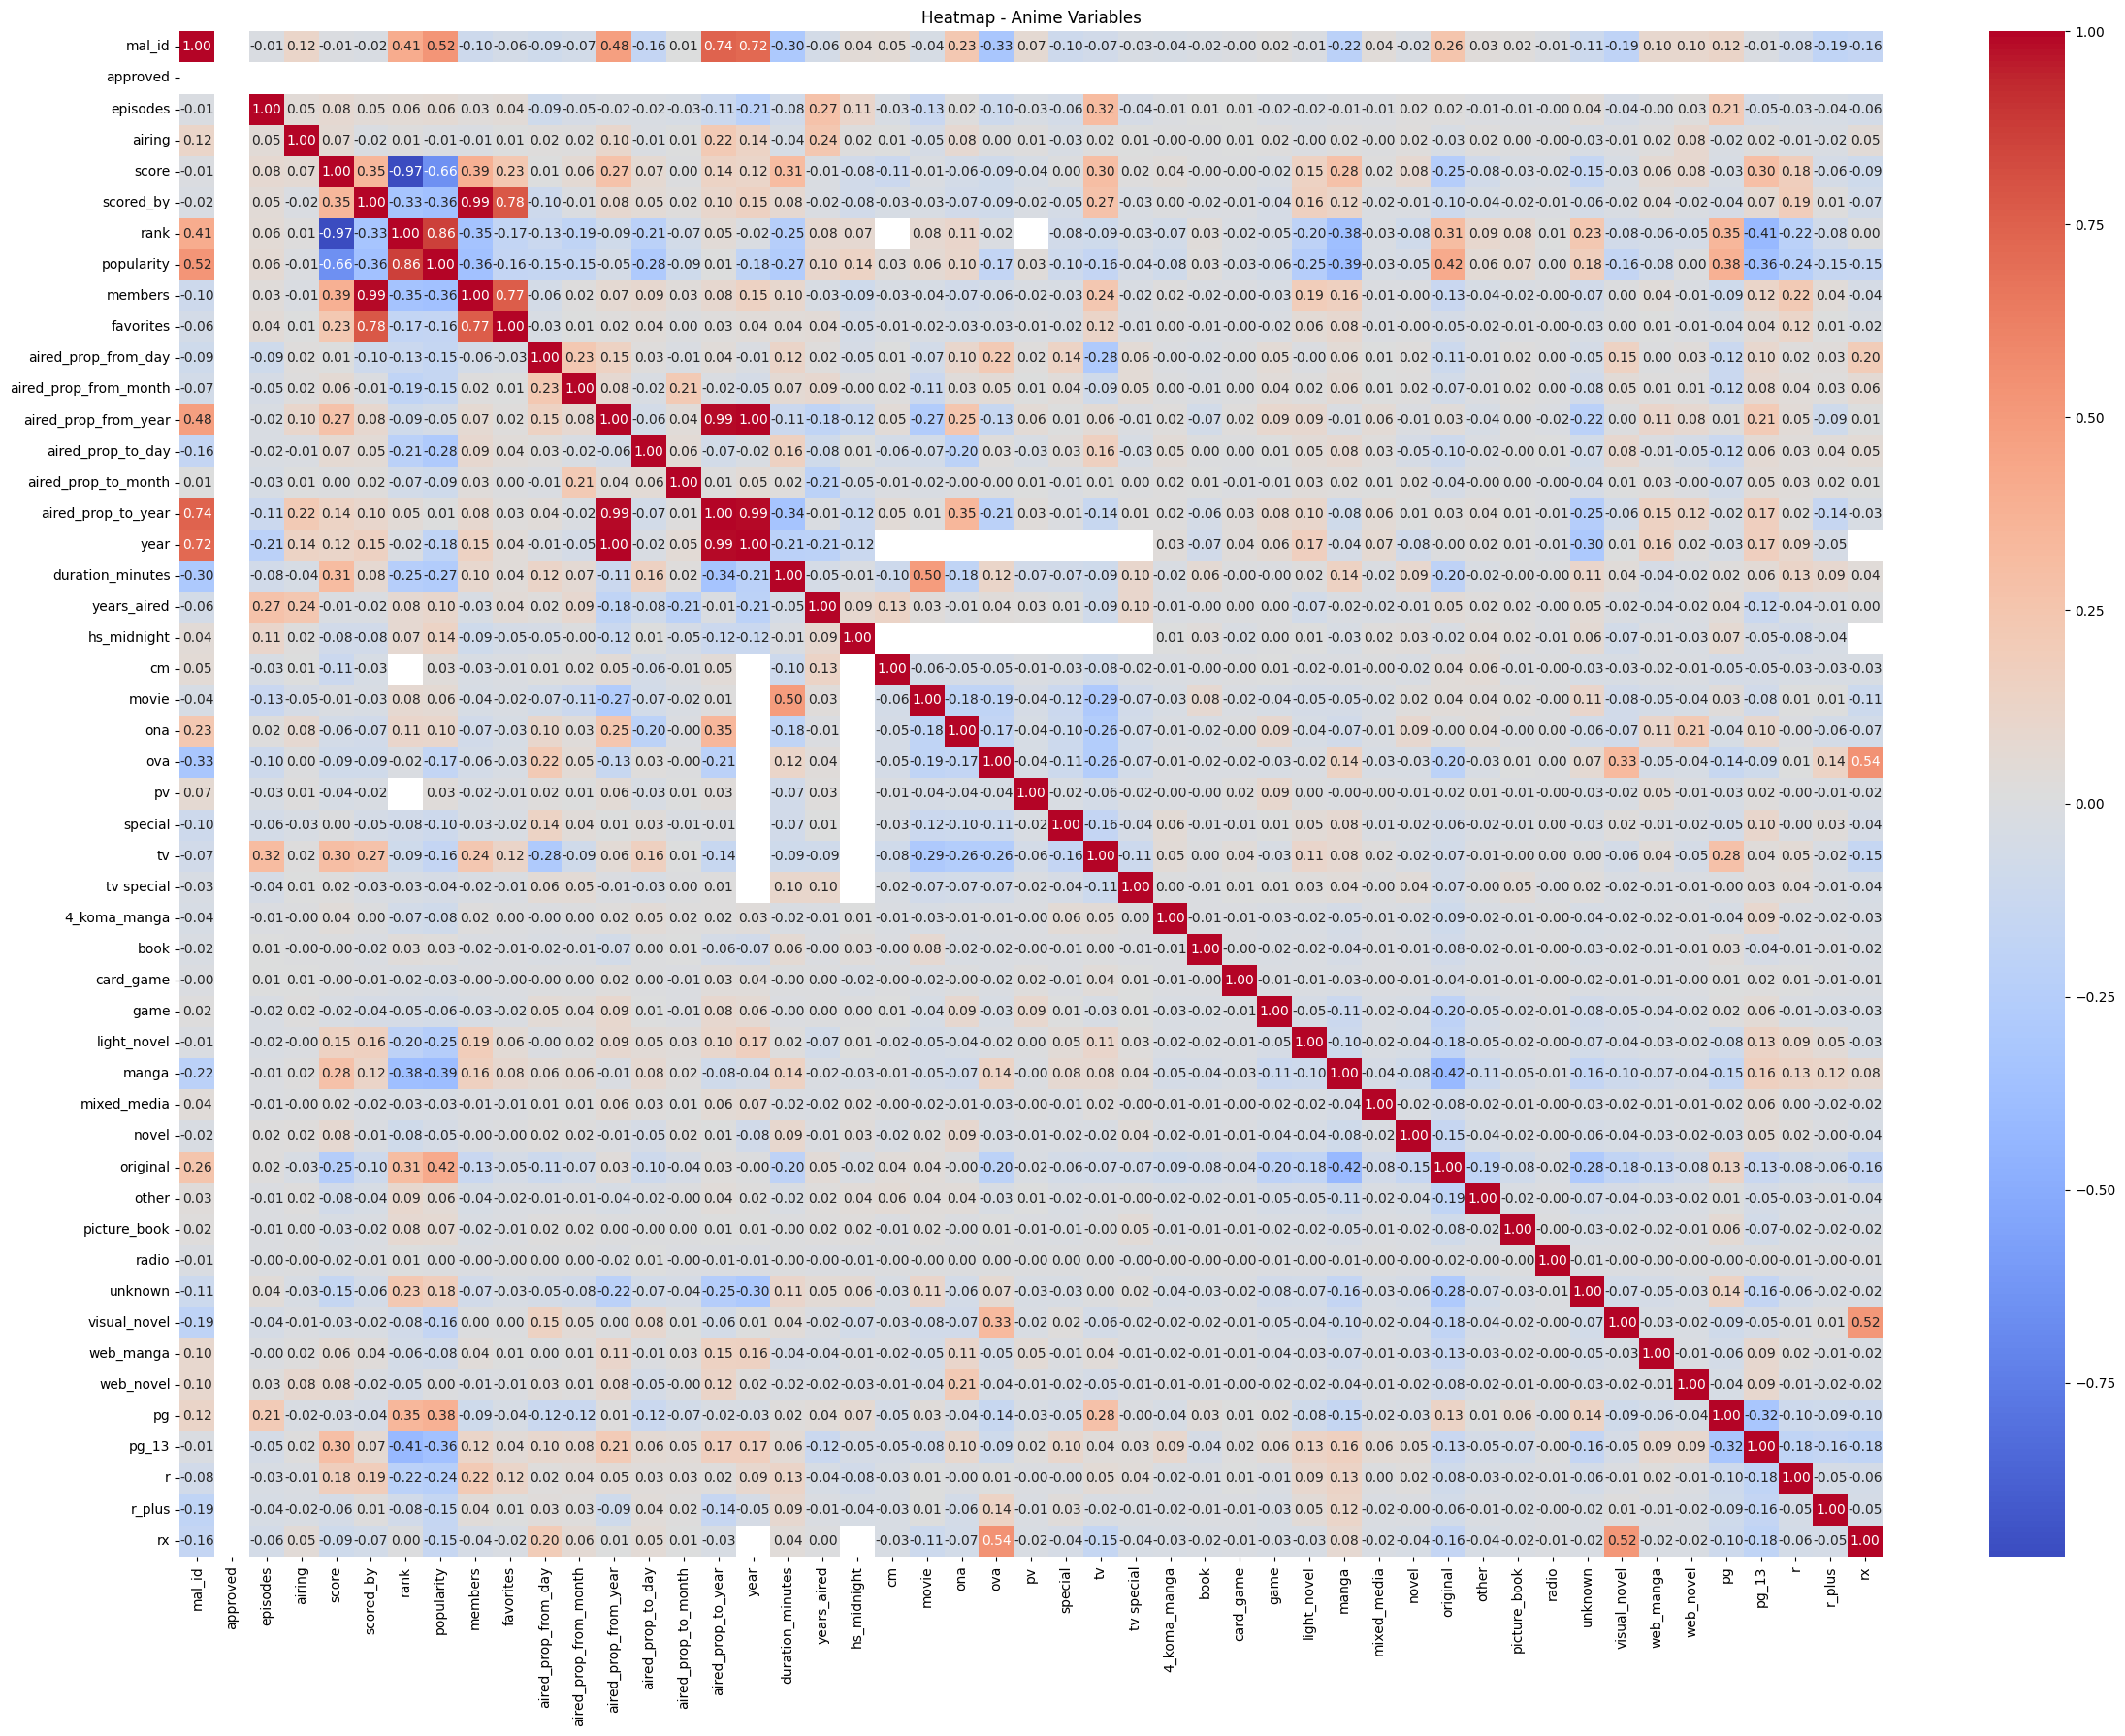

In [34]:
# Set seed for reproducibility
np.random.seed(0)

# Correlation matrix
correlation = anime.corr()

# Plot heatmap
plt.figure(figsize=(24,18))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap - Anime Variables")
plt.tight_layout()
plt.show()

In [ ]:
.......................start here
# feature reduction:
# Example with top categories
top_cats = ['catA', 'catB']  # Replace with your actual categories
df['cleaned_col'] = df['raw_col'].apply(lambda x: x if x in top_cats else 'other')

In [ ]:
'type' - format: TV/movie 
'source' - original vs manga
'episodes' - total number of episodes
'duration_minutes'
'rating' - content age rating 
'scored_by' - number of users that gave a score
'popularity' - rank based on members who have anime on list 
'members' - number of members with the anime on list (used for popularity?)
# 'aired_from' and 'aired_to' - total amount of time anime was aired 
'aired_prop_from_year' and 'aired_prop_to_year' - get number of years anime was aired 
'season' - season of year of original broadcast
'broadcast_day' - day of week anime was broadcast in japan (often null)
'broadcast_time' - time slot (in japan) that anime aired 
'studios' - studios responsible 
'genres'

'rank' - rank on list based on weighted score 
'score' - user score from 1 to 10


next...
x get number of years that anime was active


x simplify rating column (PG - Children --> PG...get distinct ratings and work from there...not needed)
x check broadcast_day for null counts - TOO MANY NULLS TO USE COLUMN
x look at format of times for broadcast_time - are AM and PM separated? yes, they use 24HR time
x are there 10 top studios? there are many studios...maybe have a categorical model later for this


are there 10 top genres?:
genre_dict = {'Comedy':'comedy', 'Fantasy':'fantasy', 'Hentai':'hentai', 'Slice of Life':'slice_of_life', 'Avant Garde':'avant_garde',
 'Action':'action', 'Adventure':'adventure', 'Drama':'drama','Horror':'horror','Mystery':'mystery','Sci-Fi':'sci_fi',
 'Romance':'romance','Suspense':'suspence', 'Supernatural':'supernatural'}


create one of these columns for each genre 
anime_df['g_comedy'] = anime_df['genres'].apply(lambda x: 'Comedy' in x.split(',') if isinstance(x, str) else False

check for collinearity - suspects:
episodes and broadcast_years
members and popularity
members and scored_by
type and duration_minutes?


target variables:
'score' (is rank the same...high collinearity)
'episodes'
